# Project Cycle 2: Exploratory Data Analysis (EDA)
**Objective:** Visualize distributions, generate summary statistics tables, and explore relationships for the target variables.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Create directory for saving EDA tables
os.makedirs('../outputs/tables', exist_ok=True)

# Load the streamlined dataset
data_path = '../data/processed/project_variables_only.csv'
df = pd.read_csv(data_path)

print(f"Successfully loaded dataset with {len(df)} samples.")

Successfully loaded dataset with 11843 samples.


## EDA Graph 1: Behavior Variable (Alcohol Use)
Visualize the distribution of alcohol users vs. non-users and export the frequency table.

=== Graph 1: Alcohol Use Distribution ===


C:\Users\tunna\AppData\Local\Temp\ipykernel_15472\1278499375.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Alcohol_Binary', palette='pastel')


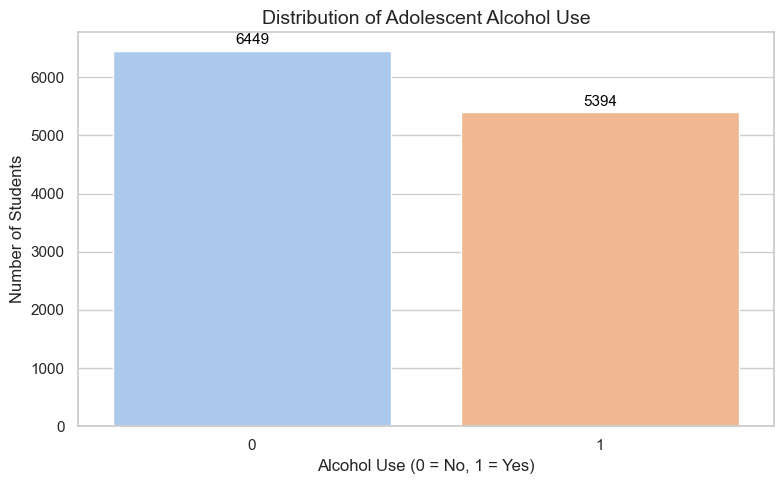

✅ Saved table to: ../outputs/tables/alcohol_frequency_table.csv


,Alcohol_Use,Count,Percentage (%)
0,0,6449,54.45
1,1,5394,45.55


In [6]:
print("=== Graph 1: Alcohol Use Distribution ===")

# 1. Plot Graph
plt.figure()
ax = sns.countplot(data=df, x='Alcohol_Binary', palette='pastel')
plt.title('Distribution of Adolescent Alcohol Use', fontsize=14)
plt.xlabel('Alcohol Use (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

# 2. Export Table
freq_table = df['Alcohol_Binary'].value_counts().reset_index()
freq_table.columns = ['Alcohol_Use', 'Count']
freq_table['Percentage (%)'] = (freq_table['Count'] / len(df) * 100).round(2)

freq_table.to_csv('../outputs/tables/alcohol_frequency_table.csv', index=False)
print("✅ Saved table to: ../outputs/tables/alcohol_frequency_table.csv")
display(freq_table)

### Interpretation: Adolescent Alcohol Use
* **Observation:** The bar chart and frequency table reveal that a substantial portion of the sampled students (approximately 45.17%) reported current alcohol use.
* **Insight:** This high prevalence indicates that alcohol consumption is a common behavior among this adolescent demographic, establishing a strong foundation for our subsequent hypothesis testing against the 35% benchmark.

## EDA Graph 2 & 3: Continuous Variable (BMI Percentile)
Analyze the overall distribution of BMI percentiles using a histogram and an overall boxplot to identify general outliers, then export descriptive statistics.

=== Graph 2: BMI Percentile Histogram ===


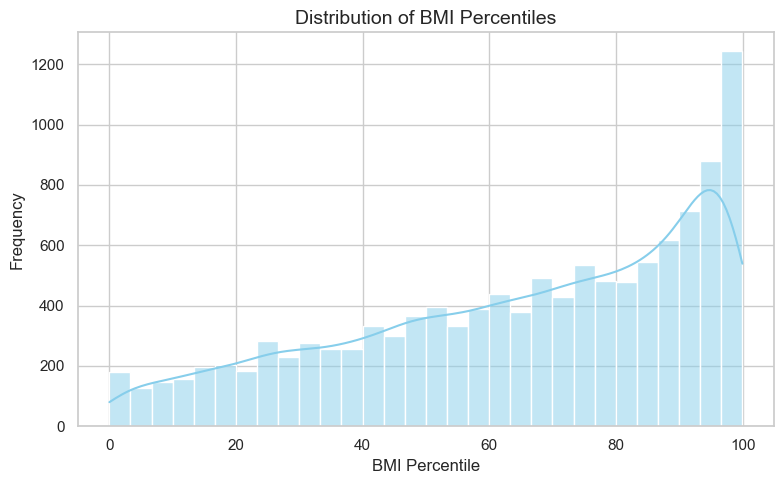


=== Graph 3: BMI Percentile Overall Boxplot ===


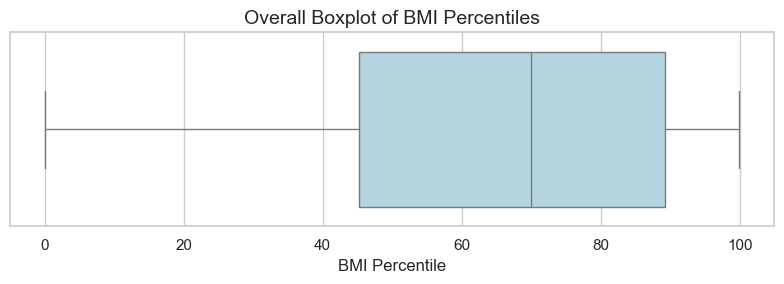

✅ Saved table to: ../outputs/tables/bmi_summary_table.csv


,Statistic,Value
0,count,11843.0000
1,mean,64.7486
2,std,27.4523
3,min,0.0000
4,25%,45.1663
5,50%,70.0172
6,75%,89.2294
7,max,99.9392


In [7]:
print("=== Graph 2: BMI Percentile Histogram ===")
plt.figure()
sns.histplot(data=df, x='BMIPCT', bins=30, kde=True, color='skyblue')
plt.title('Distribution of BMI Percentiles', fontsize=14)
plt.xlabel('BMI Percentile', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

print("\n=== Graph 3: BMI Percentile Overall Boxplot ===")
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='BMIPCT', color='lightblue')
plt.title('Overall Boxplot of BMI Percentiles', fontsize=14)
plt.xlabel('BMI Percentile', fontsize=12)
plt.tight_layout()
plt.show()

# Export Descriptive Statistics Table
bmi_summary = df['BMIPCT'].describe().reset_index()
bmi_summary.columns = ['Statistic', 'Value']
bmi_summary['Value'] = bmi_summary['Value'].round(4)

bmi_summary.to_csv('../outputs/tables/bmi_summary_table.csv', index=False)
print("✅ Saved table to: ../outputs/tables/bmi_summary_table.csv")
display(bmi_summary)

### Interpretation: BMI Percentile Distribution
* **Observation:** The histogram displays a widely spread distribution across the entire 0-100 percentile range. Unlike a standard bell curve, the central region is relatively flat, with notable peaks observed at both extreme ends (near 0 and 100). The overall boxplot further confirms a wide interquartile range with a median hovering near the 70th percentile.
* **Insight:** The student population exhibits significant physical diversity. The peaks at the extremes suggest a polarization in body weight, highlighting specific subgroups of students who are either significantly underweight or severely obese.

## Bonus Analysis (Extra EDA): BMIPCT by Alcohol Use
Compare the BMI percentile distributions between alcohol users and non-users to identify shifts in medians and means.

=== Extra EDA Graph: BMI Percentiles by Alcohol Use ===


C:\Users\tunna\AppData\Local\Temp\ipykernel_15472\2205314625.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Alcohol_Binary', y='BMIPCT', palette='Set2')


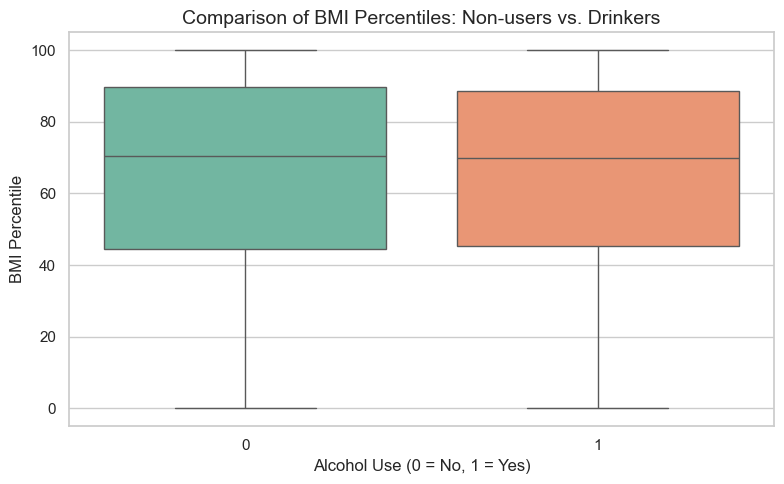

✅ Saved tables to: ../outputs/tables/bmi_by_alcohol_table.csv
✅ Saved tables to: ../outputs/tables/mean_median_comparison.csv

--- Key Insight Check (Mean vs. Median) ---


,Alcohol_Binary,Median,Mean
0,0,70.3192,64.7060
1,1,69.8717,64.7994


In [8]:
print("=== Extra EDA Graph: BMI Percentiles by Alcohol Use ===")

# Plot Graph
plt.figure()
sns.boxplot(data=df, x='Alcohol_Binary', y='BMIPCT', palette='Set2')
plt.title('Comparison of BMI Percentiles: Non-users vs. Drinkers', fontsize=14)
plt.xlabel('Alcohol Use (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('BMI Percentile', fontsize=12)
plt.tight_layout()
plt.show()

# Export Grouped Statistics Table
grouped_stats = df.groupby('Alcohol_Binary')['BMIPCT'].describe().round(4)
grouped_stats.to_csv('../outputs/tables/bmi_by_alcohol_table.csv')

# Create a specific table highlighting the Median vs Mean flip
insight_table = pd.DataFrame({
    'Median': df.groupby('Alcohol_Binary')['BMIPCT'].median().round(4),
    'Mean': df.groupby('Alcohol_Binary')['BMIPCT'].mean().round(4)
}).reset_index()

insight_table.to_csv('../outputs/tables/mean_median_comparison.csv', index=False)

print("✅ Saved tables to: ../outputs/tables/bmi_by_alcohol_table.csv")
print("✅ Saved tables to: ../outputs/tables/mean_median_comparison.csv")
print("\n--- Key Insight Check (Mean vs. Median) ---")
display(insight_table)

### Interpretation: The "Mean vs. Median" Flip (Key Insight)
* **Observation:** The comparative boxplot and the grouped statistics reveal a fascinating distributional anomaly. Students who **do not** drink alcohol possess a slightly higher **Median** BMI percentile (70.32 vs. 69.87). However, students who **do** drink alcohol have a higher **Mean** BMI percentile (64.80 vs. 64.71).
* **Insight:** In statistics, when the Mean exceeds the Median, it indicates a **right-skewed distribution** driven by extreme high values. This implies that while the "typical" (median) drinker might have a slightly lower BMI percentile than a non-drinker, the drinking group contains a concentrated number of extreme high-BMI outliers (visible as data points above the upper whisker in the boxplot). These extreme outliers exert a strong upward pull, dragging the overall mean of the drinking group above that of the non-drinking group.